# PHYS 449 - Homework 1, Question 2

**Student Name:** Allen Mathew \
**Student ID:** 20964892 \
**Due Date:** Thursday, September 11, 3:00pm 

*ChatGPT was used to help generate the code and some formulas for the questions*
- - -


2. Consider the provided Python code for a 2D Ising model with N = 256
spins on a 16 × 16 periodic lattice

(a) Produce a dataset for *T* = 1.0, 2.7 and 4.0, consisting of vectors of length *N* for
each configuration of spins. The cardinality of each dataset should be $10^{4}$.

The datasets for *T* = 1.0, 2.7, and 4.0 were easily created by manipulating the parameters for the ```run_mcmc``` function given to us. Each had a cardinality of 10,000 and vectors of length *N* = 256. We know that the energy of the Ising Model is found by:

$$E=-J\sum\limits_{\langle i,j \rangle}\sigma_i \sigma_j$$

Using the code given to us, we can plot the average energy vs. temperature for each data set:

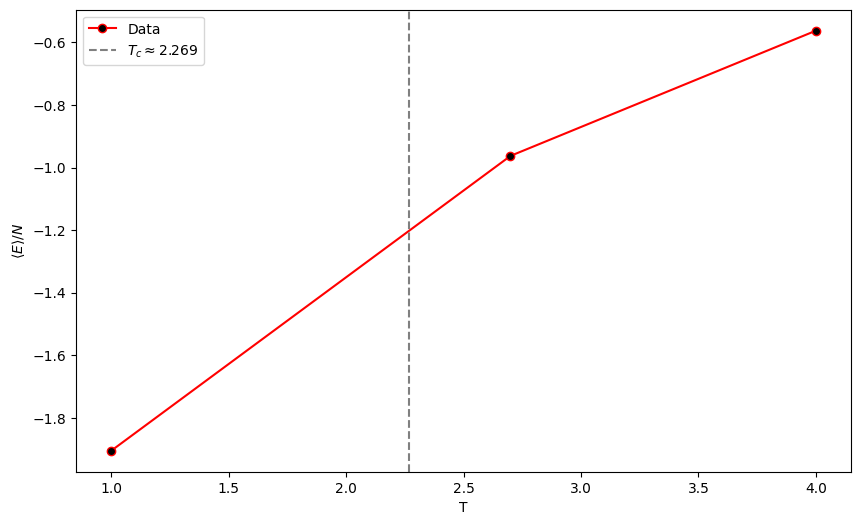

```py
Datasets:
T=1.0: (10000, 256)
T=2.7: (10000, 256)
T=4.0: (10000, 256)
```

(b) Calculate the mean and standard deviation of the energy and magnetization for
each dataset.

In [ ]:
def calc_energy(spins, L, J=1.0):
    """Compute the total energy of a spin configuration."""
    E = 0
    for i in range(L):
        for j in range(L):
            E += spins[i, j] * spins[i, (j + 1) % L]  # right neighbor
            E += spins[i, j] * spins[(i + 1) % L, j]  # bottom neighbor
    return -J * E

def calc_magnetization(spins):
    """Compute the total magnetization of a spin configuration."""
    return np.sum(spins)

def analyze_dataset(dataset, L, J=1.0):
    N = L * L
    energies = []
    mags = []

    for config in dataset:
        spins = config.reshape((L, L))
        E = calc_energy(spins, L, J)
        M = calc_magnetization(spins)
        energies.append(E / N)   # per spin
        mags.append(M / N)       # per spin

    energies = np.array(energies)
    mags = np.array(mags)

    return {
        "mean_energy": np.mean(energies),
        "std_energy": np.std(energies),
        "mean_magnetization": np.mean(mags),
        "std_magnetization": np.std(mags)
    }

results_T1  = analyze_dataset(dataset_T1,  L=16, J=1.0)
results_T27 = analyze_dataset(dataset_T27, L=16, J=1.0)
results_T4  = analyze_dataset(dataset_T4,  L=16, J=1.0)

def pretty_print(T, results):
    print(f"T = {T:.1f} : "
          f"mean_energy = {results['mean_energy']:.4f}, std_energy = {results['std_energy']:.4f}, "
          f"mean_magnetization = {results['mean_magnetization']:.4f}, std_magnetization = {results['std_magnetization']:.4f}")

pretty_print(1.0, results_T1)
pretty_print(2.7, results_T27)
pretty_print(4.0, results_T4)



We can find the mean energy per spin using the equation:

$$\frac{\langle E \rangle}{N}=\frac{1}{N_{\text{samples}}}\sum\limits_{i=1}^{N_{\text{samples}}}\frac{E_i}{N}$$

And we can find the mean magnetization per spin using the equation:

$$\frac{\langle M \rangle}{N}=\frac{1}{N_{\text{samples}}}\sum\limits_{i=1}^{N_{\text{samples}}}\frac{M_i}{N}\text{, where }M_i=\sum\limits_{j}\sigma_j$$

The standard deviation of any observable *O* is:

$$\sigma_O=\sqrt{\langle O^2 \rangle - \langle O \rangle^2}$$

```py
T = 1.0 : mean_energy = -1.9965, std_energy = 0.0216, mean_magnetization = -0.9986, std_magnetization = 0.0182
T = 2.7 : mean_energy = -0.9648, std_energy = 0.1326, mean_magnetization = -0.0285, std_magnetization = 0.2975
T = 4.0 : mean_energy = -0.5560, std_energy = 0.1018, mean_magnetization = -0.0018, std_magnetization = 0.1289
```

(c) Are your dataset sample *i.i.d.*? Define and measure an autocorrelation time for
each dataset.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Autocorrelation function ---
def autocorrelation(x, max_lag=200):
    x = np.array(x)
    n = len(x)
    x_mean = np.mean(x)
    x_var = np.var(x)

    acf = []
    for lag in range(max_lag):
        cov = np.sum((x[:n-lag] - x_mean) * (x[lag:] - x_mean)) / (n-lag)
        acf.append(cov / x_var)
    return np.array(acf)

def integrated_autocorr_time(x, max_lag=200):
    acf = autocorrelation(x, max_lag)
    return 0.5 + np.sum(acf[1:])  # exclude lag=0

# --- Analyze dataset (return energies, mags, and autocorr times) ---
def analyze_autocorr(dataset, L, J=1.0, max_lag=200):
    energies = []
    mags = []
    for config in dataset:
        spins = config.reshape((L, L))
        energies.append(calc_energy(spins, L, J))
        mags.append(calc_magnetization(spins))
    
    tau_E = integrated_autocorr_time(energies, max_lag)
    tau_M = integrated_autocorr_time(mags, max_lag)
    acf_E = autocorrelation(energies, max_lag)
    acf_M = autocorrelation(mags, max_lag)
    return energies, mags, tau_E, tau_M, acf_E, acf_M

# --- Run for all three datasets ---
results = {}
for T, dataset in [(1.0, dataset_T1), (2.7, dataset_T27), (4.0, dataset_T4)]:
    energies, mags, tau_E, tau_M, acf_E, acf_M = analyze_autocorr(dataset, L=16, J=1.0)
    results[T] = {"tau_E": tau_E, "tau_M": tau_M, "acf_E": acf_E, "acf_M": acf_M}
    print(f"T={T:.1f} : tau_E={tau_E:.2f}, tau_M={tau_M:.2f}")

# --- Plot autocorrelation functions ---
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for T, res in results.items():
    axes[0].plot(res["acf_E"], label=f"T={T}")
    axes[1].plot(res["acf_M"], label=f"T={T}")

axes[0].set_ylabel("ACF (Energy)")
axes[1].set_ylabel("ACF (Magnetization)")
axes[1].set_xlabel("Lag")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


The datasets are not *i.i.d.* (independant and identically distributed). This is becasue each new configuration depends on the spins of the previous configuration, therefore not independant of one another. However, the datasets would be identically distributed since the algorithm samples from the Boltzmann distribution.

The autocorrelation function for an observable $O_t$ is:

$$C(\tau)=\frac{\langle (O_t - \bar{O})(O_{t+\tau} - \bar{O}) \rangle}{\langle (O_t - \bar{O})^2 \rangle}$$

Feeding our data into this, we get:
```py
T=1.0 : tau_E=5.93, tau_M=6.94
T=2.7 : tau_E=5.34, tau_M=37.86
T=4.0 : tau_E=1.23, tau_M=3.24
```

and the following graph:

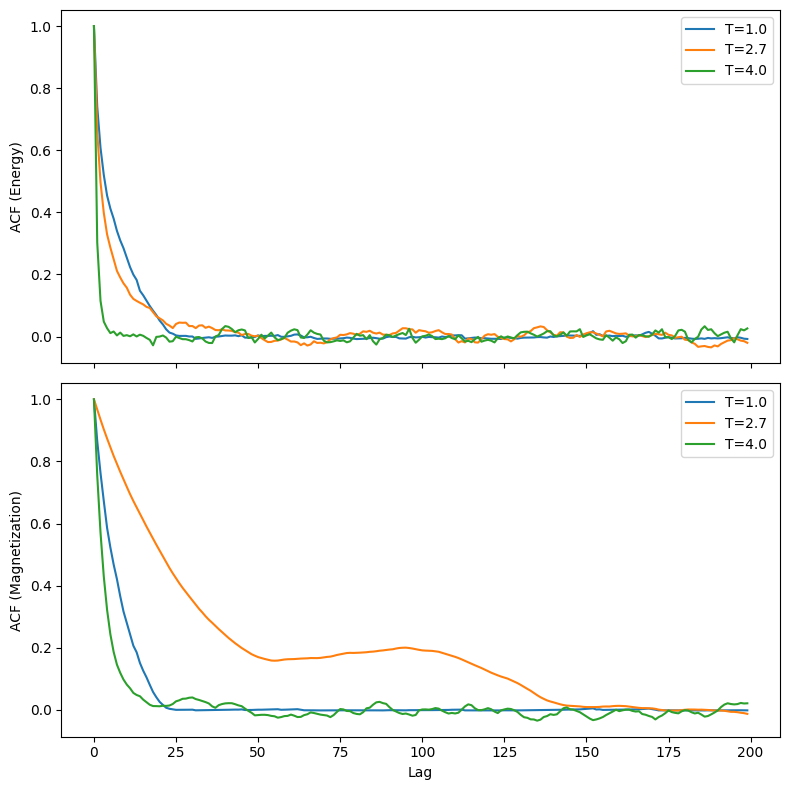

We can see that for *T* = 1.0 and 4.0, the graphs drop really quickly. But for *T* = 2.7, the graph decays slower.

(d) Recalculate your mean and standard deviation, corrected to account for the autocorrelation time.

In [ ]:
def analyze_with_autocorr(dataset, L, J=1.0, max_lag=200):
    N = L * L
    energies = []
    mags = []

    for config in dataset:
        spins = config.reshape((L, L))
        energies.append(calc_energy(spins, L, J) / N)   # per spin
        mags.append(calc_magnetization(spins) / N)      # per spin

    energies = np.array(energies)
    mags = np.array(mags)

    # raw stats
    mean_E, std_E = np.mean(energies), np.std(energies, ddof=1)
    mean_M, std_M = np.mean(mags), np.std(mags, ddof=1)

    # autocorrelation times
    tau_E = integrated_autocorr_time(energies, max_lag)
    tau_M = integrated_autocorr_time(mags, max_lag)

    # effective number of independent samples
    N_eff_E = len(energies) / (2 * tau_E)
    N_eff_M = len(mags) / (2 * tau_M)

    # corrected standard errors of the mean
    stderr_E = std_E / np.sqrt(N_eff_E)
    stderr_M = std_M / np.sqrt(N_eff_M)

    return {
        "mean_E": mean_E, "std_E": std_E, "stderr_E_corrected": stderr_E, "tau_E": tau_E,
        "mean_M": mean_M, "std_M": std_M, "stderr_M_corrected": stderr_M, "tau_M": tau_M
    }

res_T1  = analyze_with_autocorr(dataset_T1, 16)
res_T27 = analyze_with_autocorr(dataset_T27, 16)
res_T4  = analyze_with_autocorr(dataset_T4, 16)

def pretty_print(T, res):
    print(f"T={T:.1f} | "
          f"<E>={res['mean_E']:.3f} ± {res['stderr_E_corrected']:.4f} "
          f"(τ_E={res['tau_E']:.2f}), "
          f"<M>={res['mean_M']:.3f} ± {res['stderr_M_corrected']:.4f} "
          f"(τ_M={res['tau_M']:.2f})")

pretty_print(1.0, res_T1)
pretty_print(2.7, res_T27)
pretty_print(4.0, res_T4)


The standard errors we obtained in part (b) are off becasue we don't account for correlations in our samples.

The corrected error is:

$$\sigma_{\bar{O}}=\frac{\sigma_O}{\sqrt{N_{eff}}}$$

where $N_{eff}$ is the effective sample size:

$$N_{eff}=\frac{N_{samples}}{2\tau_{int}}$$

and $\tau_{int}$ is the integrated autocorrelation time:

$$\tau_{int}=\frac{1}{2}+\sum\limits_{\tau=1}^{\infty}C(\tau)$$

Recalculating everything, we get:

```py
T=1.0 | <E>=-1.996 ± 0.0007 (τ_E=5.93), <M>=-0.999 ± 0.0007 (τ_M=6.94)
T=2.7 | <E>=-0.965 ± 0.0043 (τ_E=5.34), <M>=-0.029 ± 0.0259 (τ_M=37.86)
T=4.0 | <E>=-0.556 ± 0.0016 (τ_E=1.23), <M>=-0.002 ± 0.0033 (τ_M=3.24)
```

We can see that the means remain unchanged from (b), but the corrected errors different.